In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA, TruncatedSVD

# Cargar las matrices estandarizadas 
X_train_scaled = pd.read_csv('../Datos/X_train_scaled.csv')
y_train = pd.read_csv('../Datos/y_train.csv').values.ravel()

# Lista de nombres de las especies para las leyendas del gráfico
especies_nombres = ['H. yagouaroundi', 'L. geoffroyi', 'L. guigna', 'L. pardalis', 'P. onca', 'P. concolor']

# =====================================================================
# PCA: ANÁLISIS DE COMPONENTES PRINCIPALES
# =====================================================================
# Solicitamos 2 componentes para poder visualizar el hábitat en un plano 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

# Calcular el porcentaje de varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_

# =====================================================================
# SVD: DESCOMPOSICIÓN EN VALORES SINGULARES (TruncatedSVD)
# =====================================================================
# TruncatedSVD es la versión que trabaja de forma óptima con matrices con variables dummies
svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X_train_scaled)

print("=== CONVERGENCIA DE REDUCCIÓN DE DIMENSIONES ===")
print(f"Varianza explicada por PC1: {varianza_explicada[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {varianza_explicada[1]*100:.2f}%")
print(f"Total Varianza Capturada por PCA (2D): {sum(varianza_explicada)*100:.2f}%\n")


=== CONVERGENCIA DE REDUCCIÓN DE DIMENSIONES ===
Varianza explicada por PC1: 14.51%
Varianza explicada por PC2: 12.88%
Total Varianza Capturada por PCA (2D): 27.39%



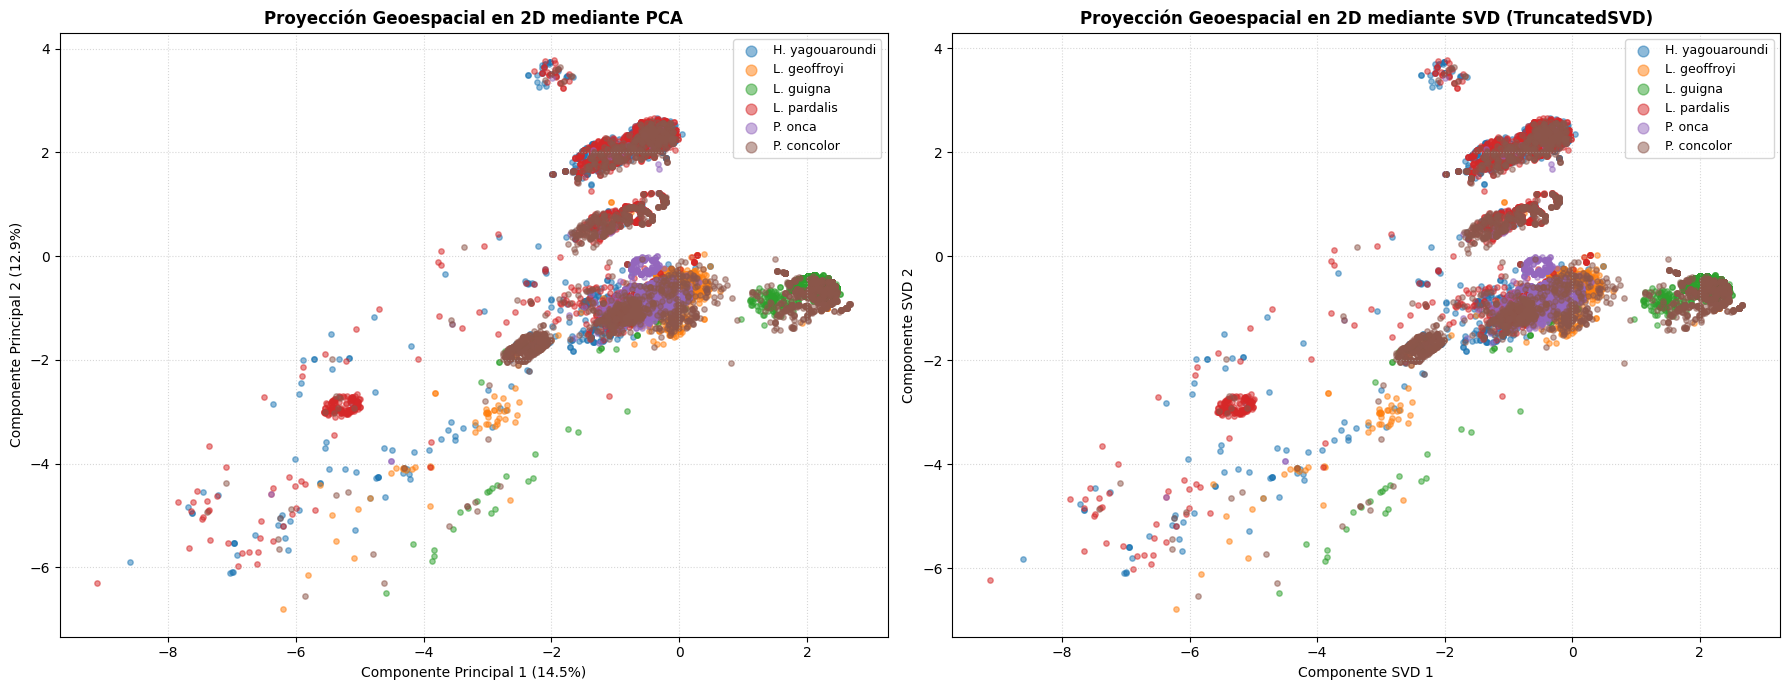

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico Izquierdo: Proyección PCA
for idx, name in enumerate(especies_nombres):
    mask = (y_train == idx)
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, alpha=0.5, s=15)

axes[0].set_title('Proyección Geoespacial en 2D mediante PCA', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'Componente Principal 1 ({varianza_explicada[0]*100:.1f}%)')
axes[0].set_ylabel(f'Componente Principal 2 ({varianza_explicada[1]*100:.1f}%)')
axes[0].legend(loc='best', markerscale=2, fontsize=9)
axes[0].grid(True, linestyle=':', alpha=0.5)

# Gráfico Derecho: Proyección SVD
for idx, name in enumerate(especies_nombres):
    mask = (y_train == idx)
    axes[1].scatter(X_svd[mask, 0], X_svd[mask, 1], label=name, alpha=0.5, s=15)

axes[1].set_title('Proyección Geoespacial en 2D mediante SVD (TruncatedSVD)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Componente SVD 1')
axes[1].set_ylabel('Componente SVD 2')
axes[1].legend(loc='best', markerscale=2, fontsize=9)
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


### Interpretación Geométrica de la Reducción y Limitaciones del Álgebra Lineal

La proyección bidimensional mediante PCA y SVD captura un **27.39% de la varianza total** del dataset. La morfología "fragmentada" y lineal de los gráficos expone un comportamiento matemático clásico de la escuela de álgebra lineal:

1.  **El Impacto de la Esparcidad Binaria:** 
    La aparición de "islas" aisladas y patrones en hileras diagonales se debe a la inclusión de variables categóricas codificadas mediante One-Hot Encoding (países y métodos de registro). Al calcular los autovectores sobre datos binarios (0 y 1), PCA y SVD se ven forzados a agrupar los datos en planos discretos rígidos, perdiendo la distribución continua del hábitat.
2.  **Confirmación de las Matrices de Confusión:**
    A pesar de la distorsión binaria, los gráficos validan visualmente nuestros hallazgos previos:
    *   **Aislamiento de la Güiña (*L. guigna*):** Se observa una nube verde perfectamente compacta y segregada a la extrema derecha del gráfico. Esto explica matemáticamente por qué KNN y LDA lograron clasificarla con un AUC casi perfecto: su espacio latente está completamente separado del resto.
    *   **La Densidad del Solapamiento Central:** En el núcleo del gráfico se observa una densa superposición de puntos correspondientes al Yaguareté (*P. onca*), el Ocelote (*L. pardalis*) y el Puma (*P. concolor*), ratificando la colinealidad geográfica de sus nichos ecológicos en las zonas tropicales.
